In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import (accuracy_score,f1_score,roc_auc_score,confusion_matrix,classification_report)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
!pip install xgboost
from xgboost import XGBClassifier


from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
TW = pd.read_csv(
    r"../classification/Twitter/Absolute_labeling/Twitter-Absolute-Sigma-500.data",
    sep=",",
    header=None
)

groups = ["NCD", 'AI', 'AS(NA)', 'BL',
         'NAC', 'AS(NAC)', 'CS', 'AT', 'NA','ADL', 'NAD']

columns = []
for group in groups:
    for t in range(7):
        columns.append(f"{group}_{t}")

columns.append("label")  # остання колонка

TW.columns = columns

TW.head(2)

,NCD_0,NCD_1,NCD_2,NCD_3,NCD_4,NCD_5,NCD_6,AI_0,AI_1,AI_2,...,ADL_5,ADL_6,NAD_0,NAD_1,NAD_2,NAD_3,NAD_4,NAD_5,NAD_6,label
0,889,939,960,805,805,1143,1121,549,613,587,...,1.0,1.0,889,939,960,805,805,1143,1121,1.0
1,542,473,504,626,647,795,832,366,288,318,...,1.0,1.0,542,473,504,626,647,795,832,1.0


In [3]:
TH = pd.read_csv(
    "../classification/TomsHardware/Absolute_labeling/TomsHardware-Absolute-Sigma-500.data",
    sep=",",
    header=None
)


groups = [
    "NCD", "BL", "NAD", "AI", "NAC", "ND",
    "CS", "AT", "NA", "ADL", "AS_NA", "AS_NAC"
]

columns = []
for group in groups:
    for t in range(8):
        columns.append(f"{group}_{t}")

columns.append("label")  # остання колонка

TH.columns = columns


prefixes = {col.split("_")[0] for col in TH.columns if "_" in col}


TH.head()

,NCD_0,NCD_1,NCD_2,NCD_3,NCD_4,NCD_5,NCD_6,NCD_7,BL_0,BL_1,...,AS_NA_7,AS_NAC_0,AS_NAC_1,AS_NAC_2,AS_NAC_3,AS_NAC_4,AS_NAC_5,AS_NAC_6,AS_NAC_7,label
0,1,0,0,0,0,0,0,1,1.0,0.0,...,0.001816,0.001211,0.000560,0.000000,0.000000,0.000161,0.0,0.000301,0.000818,1.0
1,1,1,1,1,0,0,0,0,1.0,1.0,...,0.005029,0.000784,0.000802,0.001592,0.001612,0.000741,0.0,0.000545,0.002437,1.0
2,0,0,0,0,0,0,0,0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0
3,0,0,0,0,0,0,0,0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0
4,0,0,0,0,0,0,0,0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0


### TOm HArdware

In [4]:
X = TH.drop(columns=["label"])
y = TH["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

### XGBoost baselin

In [5]:
xgb = XGBClassifier( random_state=42,eval_metric='logloss',use_label_encoder=False)
xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)
pred_proba = xgb.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, pred_xgb)
precision = precision_score(y_test, pred_xgb, zero_division=0)
recall = recall_score(y_test, pred_xgb, zero_division=0)
f1 = f1_score(y_test, pred_xgb, zero_division=0)
roc_auc = roc_auc_score(y_test, pred_proba)

print("XGBoost baseline")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")
print(f"ROC-AUC: {roc_auc}")

XGBoost baseline
Accuracy: 0.9709044908285895
Precision: 0.9812889812889813
Recall: 0.9711934156378601
F1-score: 0.9762150982419855
ROC-AUC: 0.9957107718921256


In [7]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(XGBClassifier(random_state=42,eval_metric='logloss', use_label_encoder=False),param_grid,cv=3,scoring='f1',n_jobs=-1)
grid.fit(X_train, y_train)
best_xgb = grid.best_estimator_

pred_xgb = best_xgb.predict(X_test)
pred_proba = best_xgb.predict_proba(X_test)[:, 1]


accuracy = accuracy_score(y_test, pred_xgb)
precision = precision_score(y_test, pred_xgb, zero_division=0)
recall = recall_score(y_test, pred_xgb, zero_division=0)
f1 = f1_score(y_test, pred_xgb, zero_division=0)
roc_auc = roc_auc_score(y_test, pred_proba)

print(" XGBoost with Grid Search")
print("Best params:", grid.best_params_)
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")
print(f"ROC-AUC: {roc_auc}")

 XGBoost with Grid Search
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Accuracy: 0.9702719797596457
Precision: 0.9782833505687694
Recall: 0.9732510288065843
F1-score: 0.9757607013924704
ROC-AUC: 0.9964912458526762


In [14]:
import pandas as pd

data = {
    "Model": [
        "XGBoost",
        "XGBoost with Grid Search"
    ],
    "Accuracy": [0.9709, 0.9703],
    "Precision ": [0.9813, 0.9783],
    "Recall": [0.9712, 0.9733],
    "F1-score": [0.9762, 0.9758],
    "ROC-AUC": [0.9957, 0.9965]
}

df_xgb_th = pd.DataFrame(data)
df_xgb_th

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,XGBoost,0.9709,0.9813,0.9712,0.9762,0.9957
1,XGBoost with Grid Search,0.9703,0.9783,0.9733,0.9758,0.9965


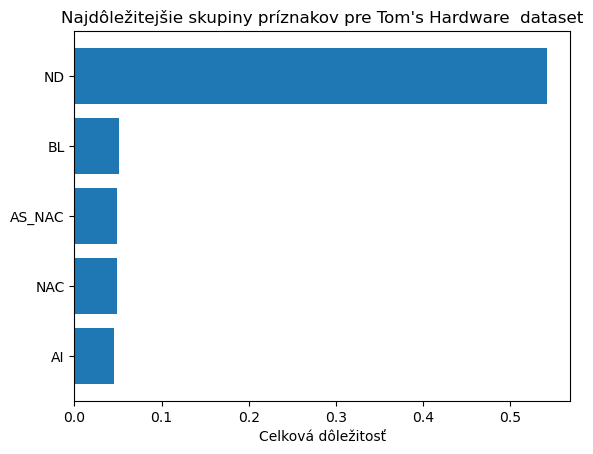

In [10]:
importances = best_xgb.feature_importances_
feature_names = X_train.columns


feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feat_imp['base_feature'] = feat_imp['feature'].apply(lambda x: x.rsplit('_', 1)[0])


grouped_importance = feat_imp.groupby('base_feature')['importance'].sum().reset_index()

grouped_importance = grouped_importance.sort_values(by='importance', ascending=False)

top_grouped = grouped_importance.head(5)

plt.figure()
plt.barh(top_grouped['base_feature'], top_grouped['importance'])
plt.gca().invert_yaxis()
plt.title("Najdôležitejšie skupiny príznakov pre Tom's Hardware  dataset")
plt.xlabel("Celková dôležitosť")
plt.show()

### Twitter

In [11]:
X = TW.drop(columns=["label"])
y = TW["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

### XGBoost baselin

In [12]:
xgb = XGBClassifier( random_state=42,eval_metric='logloss',use_label_encoder=False)
xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)
pred_proba = xgb.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, pred_xgb)
precision = precision_score(y_test, pred_xgb, zero_division=0)
recall = recall_score(y_test, pred_xgb, zero_division=0)
f1 = f1_score(y_test, pred_xgb, zero_division=0)
roc_auc = roc_auc_score(y_test, pred_proba)

print("XGBoost baseline")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")
print(f"ROC-AUC: {roc_auc}")

XGBoost baseline
Accuracy: 0.9672020467628456
Precision: 0.9260485651214128
Recall: 0.9062106210621063
F1-score: 0.9160221999818033
ROC-AUC: 0.9924476084213548


In [13]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(XGBClassifier(random_state=42,eval_metric='logloss', use_label_encoder=False),param_grid,cv=3,scoring='f1',n_jobs=-1)
grid.fit(X_train, y_train)
best_xgb = grid.best_estimator_

pred_xgb = best_xgb.predict(X_test)
pred_proba = best_xgb.predict_proba(X_test)[:, 1]


accuracy = accuracy_score(y_test, pred_xgb)
precision = precision_score(y_test, pred_xgb, zero_division=0)
recall = recall_score(y_test, pred_xgb, zero_division=0)
f1 = f1_score(y_test, pred_xgb, zero_division=0)
roc_auc = roc_auc_score(y_test, pred_proba)

print(" XGBoost with Grid Search")
print("Best params:", grid.best_params_)
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")
print(f"ROC-AUC: {roc_auc}")

 XGBoost with Grid Search
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Accuracy: 0.9689076824674863
Precision: 0.9339762611275965
Recall: 0.9065706570657066
F1-score: 0.9200694254133552
ROC-AUC: 0.9932696762836066


In [15]:
import pandas as pd

data = {
    "Model": [
        "XGBoost",
        "XGBoost with Grid Search"
    ],
    "Accuracy": [0.9672, 0.9689],
    "Precision": [0.9260, 0.9340],
    "Recall": [0.9062, 0.9066],
    "F1-score ": [0.9160, 0.9201],
    "ROC-AUC": [0.9924, 0.9933]
}

df_xgb_tw = pd.DataFrame(data)
df_xgb_tw

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,XGBoost,0.9672,0.926,0.9062,0.9160,0.9924
1,XGBoost with Grid Search,0.9689,0.934,0.9066,0.9201,0.9933


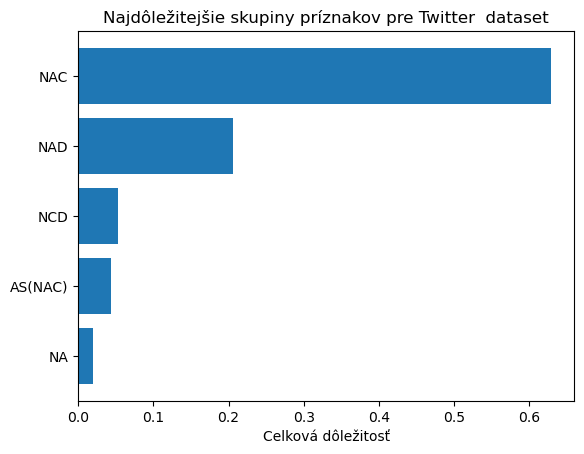

In [14]:
importances = best_xgb.feature_importances_
feature_names = X_train.columns


feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feat_imp['base_feature'] = feat_imp['feature'].apply(lambda x: x.rsplit('_', 1)[0])


grouped_importance = feat_imp.groupby('base_feature')['importance'].sum().reset_index()

grouped_importance = grouped_importance.sort_values(by='importance', ascending=False)

top_grouped = grouped_importance.head(5)


plt.figure()
plt.barh(top_grouped['base_feature'], top_grouped['importance'])
plt.gca().invert_yaxis()
plt.title("Najdôležitejšie skupiny príznakov pre Twitter  dataset")
plt.xlabel("Celková dôležitosť")
plt.show()